In [1]:
# Importing libraries used in the Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the CSV data
a=pd.read_csv('/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv')


In [5]:
# Creating a DataFrame
df=pd.DataFrame(a)


In [ ]:
# First 5 records
df.head()

In [6]:
# Bottom 5 records
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [ ]:
# Returns rows and columns
df.shape

In [8]:
# Displays list of columns in dataset
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [9]:
df.values

array([['Resort Hotel', 0, 342, ..., 0, 'Check-Out', '2015-07-01'],
       ['Resort Hotel', 0, 737, ..., 0, 'Check-Out', '2015-07-01'],
       ['Resort Hotel', 0, 7, ..., 0, 'Check-Out', '2015-07-02'],
       ...,
       ['City Hotel', 0, 34, ..., 4, 'Check-Out', '2017-09-07'],
       ['City Hotel', 0, 109, ..., 0, 'Check-Out', '2017-09-07'],
       ['City Hotel', 0, 205, ..., 2, 'Check-Out', '2017-09-07']],
      dtype=object)

### Data Preprocessing and Cleaning

In [5]:
# Dataset info like total rows & columns, datatypes, memory usage, non-null values, etc

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

***Statistical Summary***

In [9]:
# For numerical columns
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
# For non-numerical columns
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [29]:
# Checking for the missing values

df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [15]:
# for the children column, filling the  mising value with '0'

df["children"].fillna(0,inplace=True)

/tmp/ipykernel_58/814932764.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["children"].fillna(0,inplace=True)


In [172]:
# For treating null values in agent columns

df["agent"].fillna(0,inplace=True)

/tmp/ipykernel_58/110465843.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["agent"].fillna(0,inplace=True)


In [20]:
#For treating null values in company columns

df["company"].fillna(0,inplace=True)

/tmp/ipykernel_58/1246006811.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["company"].fillna(0,inplace=True)


In [24]:
# for treating null values in country column

df["country"].fillna("Unknown",inplace=True)

/tmp/ipykernel_58/167465633.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna("Unknown",inplace=True)


In [35]:
# Check for duplicates records

df.duplicated().sum()

np.int64(0)

In [34]:
# Treating duplicate values
df.drop_duplicates(inplace=True)

In [37]:
# Conversion of Datatype from 'o' to 'datetime'
df["reservation_status_date"]=pd.to_datetime(df["reservation_status_date"])

In [40]:
# returns the data type of each column
df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

***Creation of New columns***

In [41]:
# Creating a new column 'Total Guest column'

df["total_guests"]=df["adults"]+df["children"]+df["babies"]

In [42]:
# Creating a new column 'Total nights'

df["total_nights"]=df["stays_in_week_nights"]+df["stays_in_weekend_nights"]

***Metric development***

In [43]:
# Booking Lead Time

avg_lead_time = df["lead_time"].mean()

print(avg_lead_time)

79.89136802599661


In [44]:
cancellation_rate = (df["is_canceled"].mean()) * 100

print(cancellation_rate)

27.489816467572886


In [51]:
# Occupancy Metric (Average Stay Duration)

df["total_nights"] = (
    df["stays_in_week_nights"]
    + df["stays_in_weekend_nights"]
)



np.int64(87396)

In [52]:
avg_stay = df["total_nights"].mean()

print(avg_stay)

3.6306581536912446


In [53]:
average_adr = df["adr"].mean()

print(average_adr)

106.33724644148474


In [55]:
df["revenue"] = df["adr"] * df["total_nights"]
total_revenue = df["revenue"].sum()
print(total_revenue)

34460939.31


### Basic Level Questions

1. What is the average lead time for bookings?


In [58]:
# Average Lead Time

average_lead_time = df["lead_time"].mean()

print("Average Lead Time:", average_lead_time, "days")

Average Lead Time: 79.89136802599661 days


2. What is the distribution of bookings by hotel type?

In [60]:
hotel_counts = df["hotel"].value_counts()

print(hotel_counts)

hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64


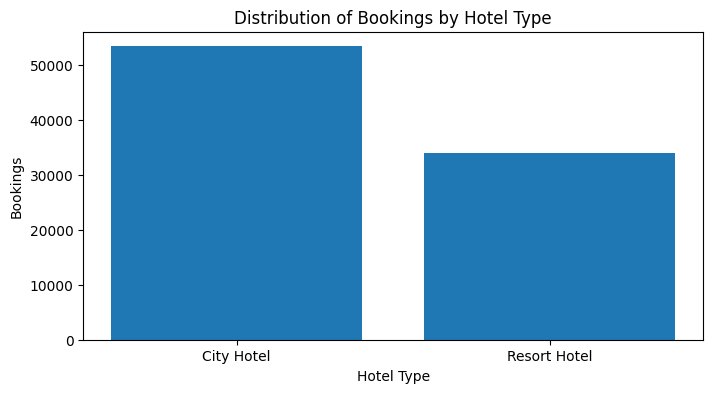

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(hotel_counts.index, hotel_counts.values)

plt.title("Distribution of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Bookings")

plt.show()

3. How many bookings were canceled?

In [76]:
total_cancelled = df["is_canceled"].sum()

In [74]:
df["is_canceled"].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

4. What is the most common arrival month for bookings?

In [139]:
month= df['arrival_date_month'].mode()

print("Most common arrival month:" , month.values)

Most common arrival month: ['August']


5. What is the average number of special requests per booking?

In [140]:
average_req=df['total_of_special_requests'].mean().round(2)
average_req

np.float64(0.57)

In [143]:
print(f"Average Special Requests per Booking: {average_req}")

Average Special Requests per Booking: 0.57


6. Which country has the highest number of bookings?


In [147]:
df['country'].value_counts().sort_values(ascending=False).head(1)

country
PRT    48590
Name: count, dtype: int64

In [150]:
# Finding country having highest number of bookings
df["country"].mode().iloc[0]

'PRT'

7. What is the average daily rate (ADR) for each hotel type?

In [92]:
df.groupby('hotel')['adr'].mean()

hotel
City Hotel      110.985944
Resort Hotel     99.025346
Name: adr, dtype: float64

8. What percentage of guests required car parking spaces?

In [157]:
df['required_car_parking_spaces'].value_counts()

required_car_parking_spaces
0    111974
1      7383
2        28
3         3
8         2
Name: count, dtype: int64

In [162]:
space=df['required_car_parking_spaces']>0
a=space.value_counts()[True]
a

np.int64(7416)

In [163]:
total_bookings = len(df)


In [188]:
per= (a/total_bookings)*100
round(per,2)

np.float64(6.21)

9. What is the average stay duration in week nights and weekend nights?


In [168]:
# Average stay duration in week nights

avg_w_nights = df["stays_in_week_nights"].mean()

print(f"Average Week Night Stay: {avg_w_nights:.2f}")

Average Week Night Stay: 2.50


In [171]:
# Average Weekend Night Stay
avg_wkd_nights = df["stays_in_weekend_nights"].mean()

print("Average Weekend Night Stay:", round(avg_wkd_nights,2))

Average Weekend Night Stay: 0.93


10.How many bookings were made through travel agents?


In [175]:
df['agent'].value_counts()

agent
9.0      31961
0.0      16340
240.0    13922
1.0       7191
14.0      3640
         ...  
197.0        1
299.0        1
388.0        1
453.0        1
480.0        1
Name: count, Length: 334, dtype: int64

In [194]:
(df['agent']!=0).value_counts()[0]

/tmp/ipykernel_58/3489214558.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (df['agent']!=0).value_counts()[0]


np.int64(103050)

In [186]:
agent_bookings = (df["agent"] != 0).sum()

print("Bookings Made Through Travel Agents:", agent_bookings)

Bookings Made Through Travel Agents: 103050


### Medium Level Questions 

1. What is the cancellation rate for each hotel type?

In [198]:
hot_type=(df.groupby('hotel')['is_canceled'].mean())*100
round(hot_type,2)

hotel
City Hotel      41.73
Resort Hotel    27.76
Name: is_canceled, dtype: float64

2. What is the average ADR per market segment?

In [201]:
df.groupby('market_segment')['adr'].mean()

market_segment
Aviation         100.142110
Complementary      2.886366
Corporate         69.358952
Direct           115.445175
Groups            79.479472
Offline TA/TO     87.354783
Online TA        117.197063
Undefined         15.000000
Name: adr, dtype: float64

3. What is the relationship between lead time and cancellation rate?

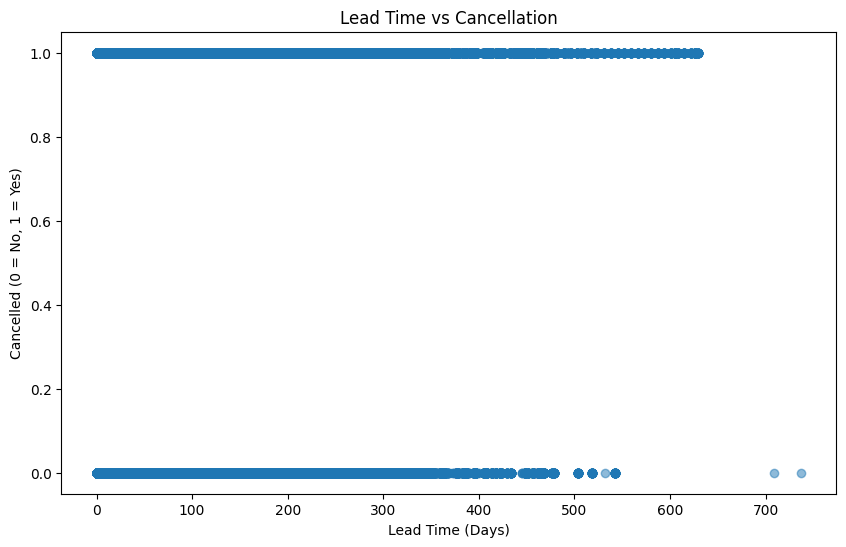

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["lead_time"],
    df["is_canceled"],
    alpha=0.3
)

plt.title("Lead Time vs Cancellation")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancelled (0 = No, 1 = Yes)")

plt.show()

In [209]:
correlation = df["lead_time"].corr(df["is_canceled"])

print(f"Correlation: {correlation:.3f}")

Correlation: 0.293


4. Which distribution channel has the highest number of bookings?

In [218]:
df['distribution_channel'].value_counts().idxmax()

'TA/TO'

5. What is the average number of previous cancellations by hotel type?

In [120]:
df.groupby('hotel')['previous_cancellations'].mean()

hotel
City Hotel      0.079743
Resort Hotel    0.101722
Name: previous_cancellations, dtype: float64

6. What is the trend of ADR over the years?

In [5]:
adr_year = (
    df.groupby("arrival_date_year")["adr"]
      .mean()
)

adr_year

arrival_date_year
2015     87.178515
2016     98.325863
2017    114.637950
Name: adr, dtype: float64

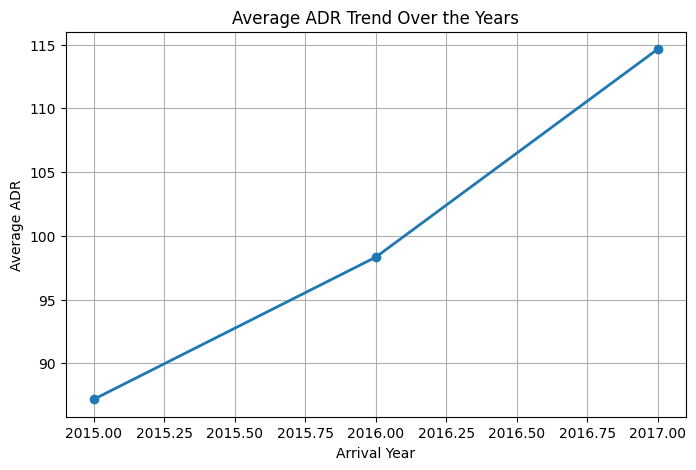

In [221]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    adr_year.index,
    adr_year.values,
    marker="o",
    linewidth=2
)

plt.title("Average ADR Trend Over the Years")
plt.xlabel("Arrival Year")
plt.ylabel("Average ADR")

plt.grid(True)

plt.show()

7. Which month has the highest revenue?

In [8]:
month=df.groupby('arrival_date_month')['adr'].sum().sort_values(ascending=False)

In [9]:
month.idxmax()

'August'

8. What is the impact of special requests on ADR?

In [11]:
corelation=df['total_of_special_requests'].corr(df['adr'])
print("Correlation: ",round(corelation,2))

Correlation:  0.172


9.What is the average stay duration for repeated guests versus new guests?

In [133]:
df["total_nights"]=df["stays_in_week_nights"]+df["stays_in_weekend_nights"]

In [134]:
df.groupby('is_repeated_guest')['total_nights'].mean()

is_repeated_guest
0    3.477410
1    1.925984
Name: total_nights, dtype: float64

10.Which room type has the highest number of bookings? 

In [12]:
df['reserved_room_type'].value_counts().idxmax()

'A'

### Advanced Level Questions

1.What factors significantly impact the cancellation rate?

In [17]:
# Scikit-learn (often written as sklearn) is Python's most widely used Machine Learning library
# train_test_split divide data into training and testing


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression   # imports the Logistic Regression algorithm.
import pandas as pd

# Independent variables
X = df[["lead_time", "booking_changes", "total_of_special_requests"]]

# Target variable
y = df["is_canceled"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,               # 80% data(Training), 20%data(Testing)
    random_state=42               # To reduce risk of different splits each time, By fixing the random state by a contant
)

# Train Logistic Regression model
new_model = LogisticRegression()       # Creating the model, it is empty at first.
new_model.fit(X_train, y_train)        # Train the model to learn the relationship between the selected feature and whether a booking gets cancelled

# Display coefficients
final_r = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": new_model.coef_[0]
})

print(final_r)


# A positive coefficient means an increase the chance of cancellations
# Negative coefficient means decrease the chance of cancellations


                     Feature  Coefficient
0                  lead_time     0.005817
1            booking_changes    -0.750351
2  total_of_special_requests    -0.681012


2.How does the ADR vary with the number of adults, children, and babies?


In [14]:
# Selecting Library
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd


# Select variable
x = df[["adults", "children", "babies"]]
y = df["adr"]


#Splitting the dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Apply Multiple Linear Regression
my_model = LinearRegression()
my_model.fit(x_train, y_train)


# Display the Effect of Each Variable on ADR
my_result = pd.DataFrame({
    "Variable": x.columns,
    "Coefficient": my_model.coef_
})

print(my_result)

   Variable  Coefficient
0    adults    20.011154
1  children    40.114801
2    babies     8.352402


In [13]:
# Since i have received error: X contains NaN

#df[["adults", "children", "babies", "adr"]].isnull().sum()
#df = df.dropna(subset=["children"])

3. What is the impact of booking changes on guest satisfaction as indicated by special requests?

In [32]:
correlation = df["booking_changes"].corr(df["total_of_special_requests"])

print("Correlation:", round(correlation, 3))

Correlation: 0.053


4.What is the seasonal impact on booking cancellations?

In [34]:
cancel = (
    df.groupby("arrival_date_month")["is_canceled"]
      .mean()
      .reset_index()
)

print(cancel)

   arrival_date_month  is_canceled
0               April     0.407972
1              August     0.377352
2            December     0.349705
3            February     0.334160
4             January     0.304773
5                July     0.374536
6                June     0.414572
7               March     0.321523
8                 May     0.396658
9            November     0.312334
10            October     0.380466
11          September     0.391702


5. How does the booking lead time distribution vary between different market segments?


<Figure size 1200x600 with 0 Axes>

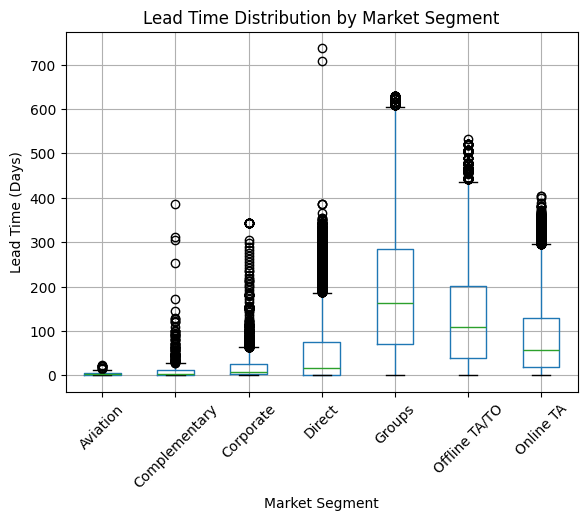

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df.boxplot(
    column="lead_time",
    by="market_segment",
    rot=45
)

plt.title("Lead Time Distribution by Market Segment")
plt.suptitle("")
plt.xlabel("Market Segment")
plt.ylabel("Lead Time (Days)")

plt.show()